Accuracy: 84.00%

Confusion Matrix:
 [[23  4]
 [ 4 19]]


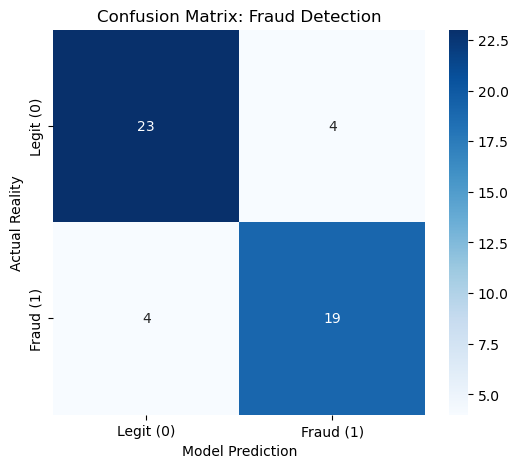

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. THE DATA (Synthetic Banking Data)
# Imagine higher transaction amounts have a higher chance of being fraud
np.random.seed(42)
n_samples = 200
transaction_amount = np.random.rand(n_samples, 1) * 1000  # Amounts $0 - $1000

# We create a "probability" based on amount, then flip a coin
# This creates the "S-Curve" relationship naturally
probabilities = 1 / (1 + np.exp(-(0.01 * transaction_amount - 5)))
is_fraud = (np.random.rand(n_samples, 1) < probabilities).astype(int).ravel()

# 2. THE SPLIT
X_train, X_test, y_train, y_test = train_test_split(transaction_amount, is_fraud, test_size=0.25, random_state=42)

# 3. TRAINING (The Gatekeeper)
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. PREDICTION
predictions = model.predict(X_test)

# 5. EVALUATION (The Confusion Matrix)
conf_matrix = confusion_matrix(y_test, predictions)
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.2%}")
print("\nConfusion Matrix:\n", conf_matrix)

# Visualization of Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit (0)', 'Fraud (1)'],
            yticklabels=['Legit (0)', 'Fraud (1)'])
plt.ylabel('Actual Reality')
plt.xlabel('Model Prediction')
plt.title('Confusion Matrix: Fraud Detection')
plt.show()